# Shared Prefix Sweep Benchmark Results

This notebook visualizes the benchmark results for shared prefix caching. The x-axis represents the prefix-cache usage rate (i.e. the sweep value) and the y-axis represents the median time-to-first-token (TTFT) in milliseconds.

Two metrics were swept:
- **Prefix Reuse Rate**: computed as `prompts_per_group / total_requests` (with total_requests fixed at 1024)
- **Prefix Length Ratio**: computed as `system_prompt_len / total_request_len` (with total_request_len fixed at 2176)

The two metrics intersect at the default values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

available_metrics = {
    "duration": "Benchmark Duration (s)",
    "completed": "Completed Requests",
    # "request_throughput": "Request Throughput (req/s)",
    # "input_throughput": "Input Throughput (tokens/s)",
    # "output_throughput": "Output Throughput (tokens/s)",
    # "mean_ttft_ms": "Mean TTFT (ms)",
    "median_ttft_ms": "Median TTFT (ms)",
    # "std_ttft_ms": "Std Dev TTFT (ms)",
    # "p99_ttft_ms": "P99 TTFT (ms)",
    # "mean_tpot_ms": "Mean TPOT (ms)",
    # "median_tpot_ms": "Median TPOT (ms)",
    # "std_tpot_ms": "Std Dev TPOT (ms)",
    # "p99_tpot_ms": "P99 TPOT (ms)",
    # "mean_itl_ms": "Mean ITL (ms)",
    "median_itl_ms": "Median ITL (ms)",
    # "std_itl_ms": "Std Dev ITL (ms)",
    # "p99_itl_ms": "P99 ITL (ms)",
    "mean_e2e_latency_ms": "Mean E2E Latency (ms)",
    "median_e2e_latency_ms": "Median E2E Latency (ms)",
}

In [2]:
def plot_metric(metric):
    # Load results from a single CSV file
    df = pd.read_csv('chosen_results.csv')
    df = df[df['gpu_type'] != 'gpu_type']
    df['sweep_value'] = pd.to_numeric(df['sweep_value'], errors='raise')
    df[metric] = pd.to_numeric(df[metric], errors='raise')
    # Separate data for the two sweep types
    df_prefix_reuse_rate_single_gpu = df[(df['sweep_type'] == 'prefix_reuse_rate') & (df['num_servers'] == 1)]
    df_prefix_reuse_rate_four_gpu = df[(df['sweep_type'] == 'prefix_reuse_rate') & (df['num_servers'] == 4)]
    # df_prefix_length_ratio = df[df['sweep_type'] == 'prefix_length_ratio']

    if metric not in available_metrics:
        print("Invalid metric.")
        return

    # Plot the results
    plt.figure(figsize=(5, 3))
    plt.plot(df_prefix_reuse_rate_single_gpu['sweep_value'], df_prefix_reuse_rate_single_gpu[metric], marker='o', label='Prefix Reuse Rate (1 GPU)')
    plt.plot(df_prefix_reuse_rate_four_gpu['sweep_value'], df_prefix_reuse_rate_four_gpu[metric], marker='s', label='Prefix Reuse Rate (4 GPUs)')
    # plt.plot(df_prefix_length_ratio['sweep_value'], df_prefix_length_ratio[metric], marker='s', label='Prefix Length Ratio')

    plt.ylim(0, None)
    plt.xlabel('Prefix-cache Usage Rate')
    plt.ylabel(available_metrics[metric])
    plt.title('Shared Prefix Benchmark Results')
    plt.legend()
    plt.grid(True)
    plt.show()

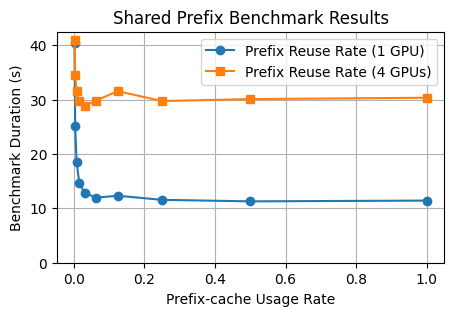

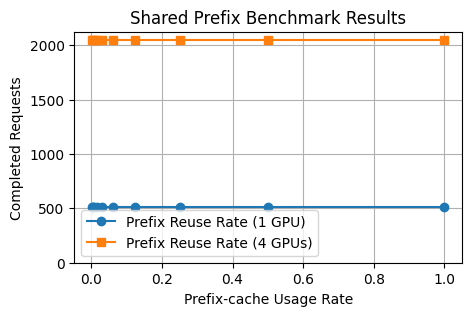

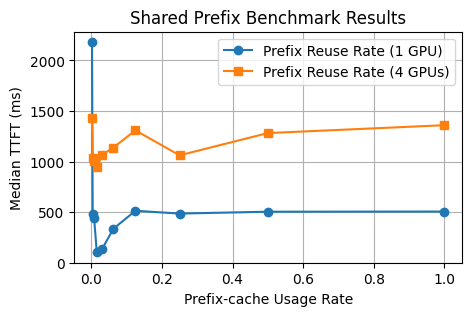

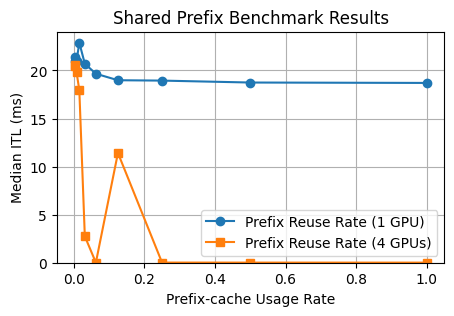

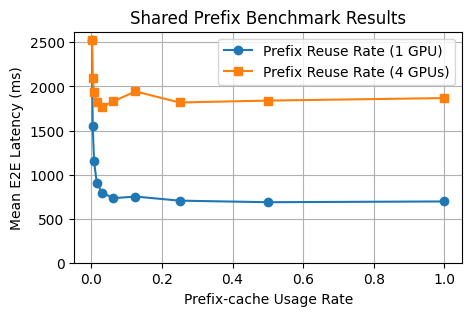

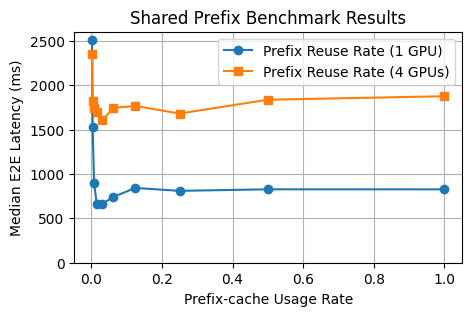

In [3]:
for metric in available_metrics:
    plot_metric(metric)